In [ ]:
##IMPORTING DATA SET AND PREPROCESSING

#mounting drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#importing data set

import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/Data Viz/Raw Data/Indicator-92266-DATA.csv")
df.head()


,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
0,92266,General fertility rate,NaN,NaN,E92000001,England,England,Female,15-44 yrs,NaN,...,687007.0,10718101.0,NaN,NaN,Not compared,Not compared,20100000,NaN,NaN,1y
1,92266,General fertility rate,E92000001,England,E06000001,Hartlepool,UA,Female,15-44 yrs,NaN,...,1134.0,17895.0,NaN,NaN,Similar,Not compared,20100000,NaN,NaN,1y
2,92266,General fertility rate,E92000001,England,E06000002,Middlesbrough,UA,Female,15-44 yrs,NaN,...,2138.0,28283.0,NaN,NaN,Higher,Not compared,20100000,NaN,NaN,1y
3,92266,General fertility rate,E92000001,England,E06000003,Redcar and Cleveland,UA,Female,15-44 yrs,NaN,...,1585.0,25185.0,NaN,NaN,Similar,Not compared,20100000,NaN,NaN,1y
4,92266,General fertility rate,E92000001,England,E06000004,Stockton-on-Tees,UA,Female,15-44 yrs,NaN,...,2478.0,38093.0,NaN,NaN,Similar,Not compared,20100000,NaN,NaN,1y


In [ ]:
#no. of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3072
Number of columns: 27


In [ ]:
#analysing columns

column_names = df.columns
print(column_names)

Index(['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name',
       'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type',
       'Category', 'Time period', 'Value', 'Lower CI 95.0 limit',
       'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit',
       'Count', 'Denominator', 'Value note', 'Recent Trend',
       'Compared to England value or percentiles', 'Column not used',
       'Time period Sortable', 'New data', 'Compared to goal',
       'Time period range'],
      dtype='object')


In [ ]:
#removing unwanted columns


columns_needed = [
    'Area Code',
    'Area Name',
    'Area Type',
    'Parent Name', # Added 'Parent Name' here
    'Category',
    'Category Type',
    'Time period',
    'Value',  # Re-adding the 'Value' column
    'Count',
    'Denominator',
    'Time period range'
]

df_selected = df[columns_needed]

print(df_selected.head())

   Area Code             Area Name Area Type Parent Name Category  \
0  E92000001               England   England         NaN      NaN   
1  E06000001            Hartlepool        UA     England      NaN   
2  E06000002         Middlesbrough        UA     England      NaN   
3  E06000003  Redcar and Cleveland        UA     England      NaN   
4  E06000004      Stockton-on-Tees        UA     England      NaN   

  Category Type  Time period      Value     Count  Denominator  \
0           NaN         2010  64.097829  687007.0   10718101.0   
1           NaN         2010  63.369656    1134.0      17895.0   
2           NaN         2010  75.593112    2138.0      28283.0   
3           NaN         2010  62.934286    1585.0      25185.0   
4           NaN         2010  65.051322    2478.0      38093.0   

  Time period range  
0                1y  
1                1y  
2                1y  
3                1y  
4                1y  


In [ ]:
# Ensuring values are numeric

df_selected = df_selected[df_selected['Category Type'].isna()].copy()
df_selected['Value'] = pd.to_numeric(df_selected['Value'], errors='coerce')
df_selected['Time period'] = pd.to_numeric(df_selected['Time period'], errors='coerce')

In [ ]:
#Analysing the rows

df_selected['Area Type'].value_counts()



,count
Area Type,
UA,1844
District,328
County,300
CCG,214
Regions (statistical),126
ICB sub-locations,67
Combined authorities,20
England,14
PHE Centre,9


In [ ]:
#Creating the England (National) data set
# Filter rows where Area Type is 'England'
df_england = df_selected[df_selected['Area Type'] == 'England']

# View the filtered rows
print(df_england)


      Area Code Area Name Area Type Parent Name Category Category Type  \
0     E92000001   England   England         NaN      NaN           NaN   
455   E92000001   England   England         NaN      NaN           NaN   
628   E92000001   England   England         NaN      NaN           NaN   
801   E92000001   England   England         NaN      NaN           NaN   
974   E92000001   England   England         NaN      NaN           NaN   
1147  E92000001   England   England         NaN      NaN           NaN   
1320  E92000001   England   England         NaN      NaN           NaN   
1493  E92000001   England   England         NaN      NaN           NaN   
1666  E92000001   England   England         NaN      NaN           NaN   
1839  E92000001   England   England         NaN      NaN           NaN   
2012  E92000001   England   England         NaN      NaN           NaN   
2185  E92000001   England   England         NaN      NaN           NaN   
2358  E92000001   England   England   

In [ ]:
# Keep only rows where Category is NaN (these are the national sum rows)
df_england_sum = df_england[df_england['Category'].isna()]
print(df_england_sum)


#save data frame to drive
csv_path = "/content/drive/MyDrive/Data Viz/Processed Data/df_england_sum.csv"
df_england_sum.to_csv(csv_path, index=False)


      Area Code Area Name Area Type Parent Name Category Category Type  \
0     E92000001   England   England         NaN      NaN           NaN   
455   E92000001   England   England         NaN      NaN           NaN   
628   E92000001   England   England         NaN      NaN           NaN   
801   E92000001   England   England         NaN      NaN           NaN   
974   E92000001   England   England         NaN      NaN           NaN   
1147  E92000001   England   England         NaN      NaN           NaN   
1320  E92000001   England   England         NaN      NaN           NaN   
1493  E92000001   England   England         NaN      NaN           NaN   
1666  E92000001   England   England         NaN      NaN           NaN   
1839  E92000001   England   England         NaN      NaN           NaN   
2012  E92000001   England   England         NaN      NaN           NaN   
2185  E92000001   England   England         NaN      NaN           NaN   
2358  E92000001   England   England   

In [ ]:
df_england_sum['Area Type'].value_counts()

#now we have the 14 rows

,count
Area Type,
England,14


In [ ]:
#Creating the Regions (statistical) data set

# Filter rows where Area Type is 'Regions (statistical)'
df_Regions = df_selected[df_selected['Area Type'] == 'Regions (statistical)']

# View the filtered rows
print(df_Regions)

#shape
df_Regions.shape[0]

#save data frame to drive
csv_path = "/content/drive/MyDrive/Data Viz/Processed Data/df_Regions.csv"
df_england_sum.to_csv(csv_path, index=False)

      Area Code                                      Area Name  \
156   E12000001                North East region (statistical)   
157   E12000002                North West region (statistical)   
158   E12000003  Yorkshire and the Humber region (statistical)   
159   E12000004             East Midlands region (statistical)   
160   E12000005             West Midlands region (statistical)   
...         ...                                            ...   
3057  E12000005             West Midlands region (statistical)   
3058  E12000006           East of England region (statistical)   
3059  E12000007                    London region (statistical)   
3060  E12000008                South East region (statistical)   
3061  E12000009                South West region (statistical)   

                  Area Type Parent Name Category Category Type  Time period  \
156   Regions (statistical)     England      NaN           NaN         2010   
157   Regions (statistical)     England      NaN 

In [ ]:
#Creating the Districts data set
df_districts = df_selected[df_selected['Area Type'] == 'District']

# View the filtered rows
print(df_districts)

#shape
df_districts.shape[0]


#save data frame to drive
csv_path = "/content/drive/MyDrive/Data Viz/Processed Data/df_districts.csv"
df_england_sum.to_csv(csv_path, index=False)

      Area Code             Area Name Area Type Parent Name Category  \
2442  E07000008             Cambridge  District     England      NaN   
2443  E07000009   East Cambridgeshire  District     England      NaN   
2444  E07000010               Fenland  District     England      NaN   
2445  E07000011       Huntingdonshire  District     England      NaN   
2446  E07000012  South Cambridgeshire  District     England      NaN   
...         ...                   ...       ...         ...      ...   
2958  E07000241       Welwyn Hatfield  District     England      NaN   
2959  E07000242    East Hertfordshire  District     England      NaN   
2960  E07000243             Stevenage  District     England      NaN   
2961  E07000244          East Suffolk  District     England      NaN   
2962  E07000245          West Suffolk  District     England      NaN   

     Category Type  Time period     Value   Count  Denominator  \
2442           NaN         2022  30.07022  1229.0      40871.0   
244

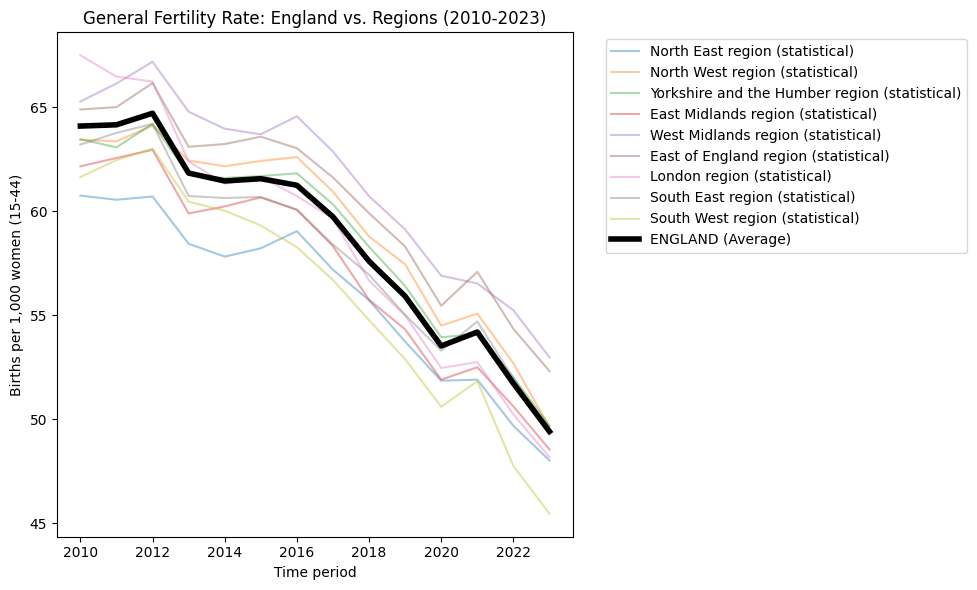

In [ ]:
##EXPLORATORY DATA ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns

#Visualisation 1:

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_Regions, x='Time period', y='Value', hue='Area Name', alpha=0.4)
sns.lineplot(data=df_england_sum, x='Time period', y='Value', color='black', linewidth=4, label='ENGLAND (Average)')
plt.title('General Fertility Rate: England vs. Regions (2010-2023)')
plt.ylabel('Births per 1,000 women (15-44)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data Viz//Processed Data/viz1_national_vs_regional.png')

/tmp/ipython-input-241018077.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reg_changes = df_Regions.groupby('Area Name').apply(get_pct_change).sort_values()


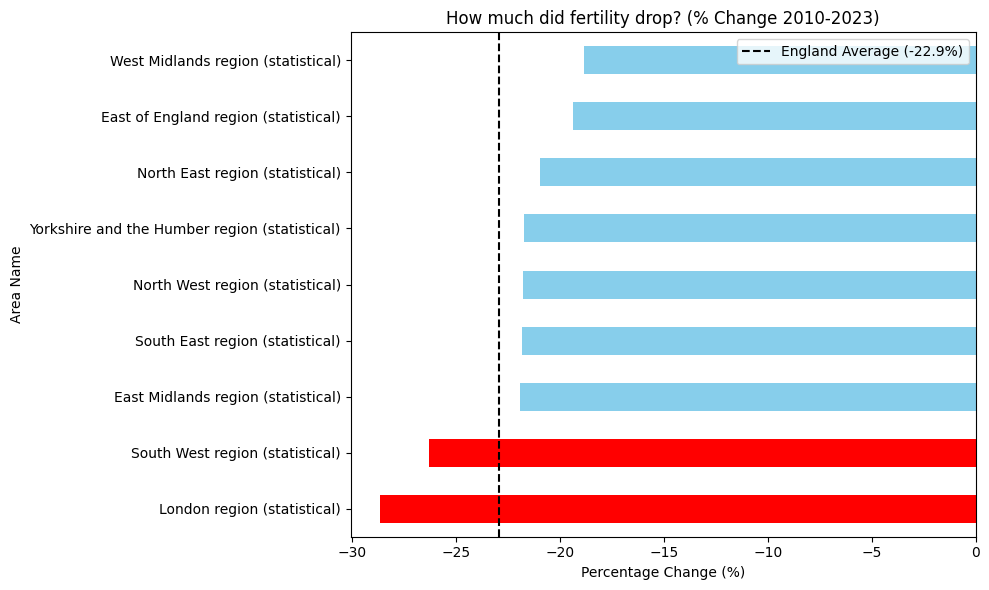

In [ ]:
#Visualisation 2: Percent Change

# Calculating % change from 2010 to 2023 for each region and England
def get_pct_change(group):
    v2010 = group[group['Time period'] == 2010]['Value'].values
    v2023 = group[group['Time period'] == 2023]['Value'].values
    if len(v2010) > 0 and len(v2023) > 0:
        return ((v2023[0] - v2010[0]) / v2010[0]) * 100
    return None

reg_changes = df_Regions.groupby('Area Name').apply(get_pct_change).sort_values()
eng_change = get_pct_change(df_england_sum)

plt.figure(figsize=(10, 6))
colors = ['red' if x < eng_change else 'skyblue' for x in reg_changes]
reg_changes.plot(kind='barh', color=colors)
plt.axvline(eng_change, color='black', linestyle='--', label=f'England Average ({eng_change:.1f}%)')
plt.title('How much did fertility drop? (% Change 2010-2023)')
plt.xlabel('Percentage Change (%)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data Viz/Processed Data/viz2_fertility_drop.png')

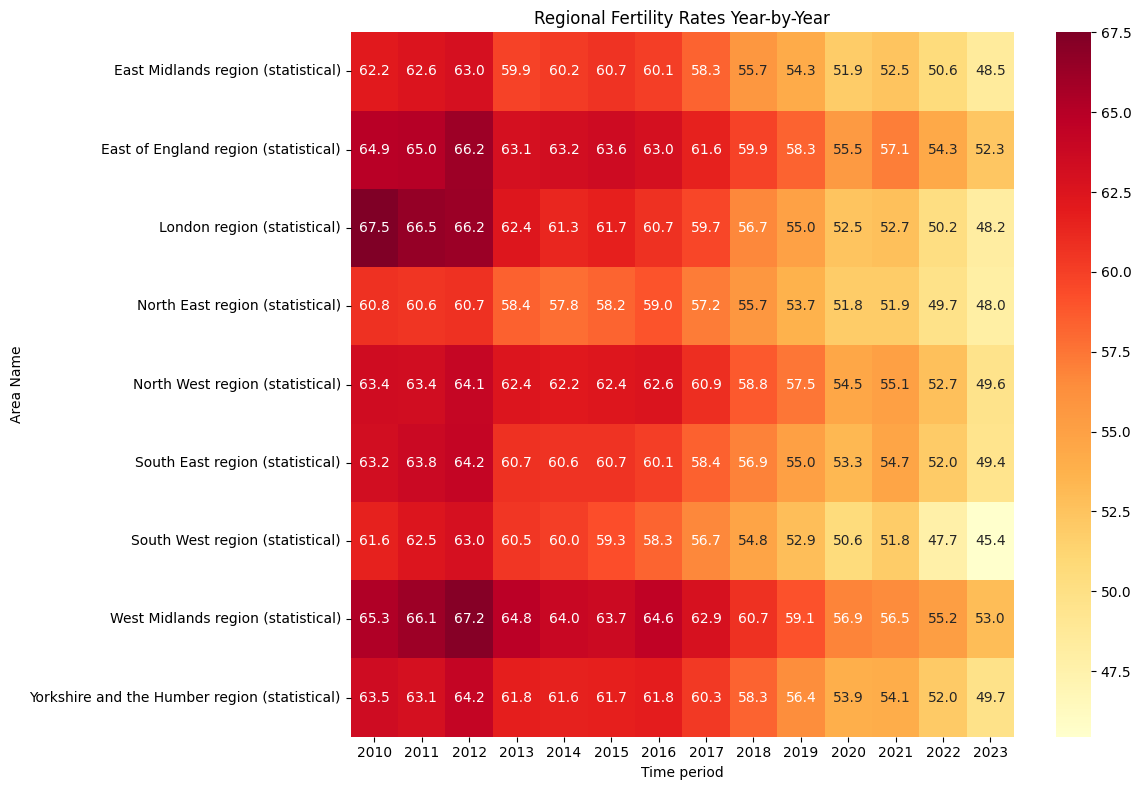

In [ ]:
#Visualisation 3:Heatmap

pivot_reg = df_Regions.pivot(index='Area Name', columns='Time period', values='Value')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_reg, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('Regional Fertility Rates Year-by-Year')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data Viz/Processed Data/viz3_heatmap.png')

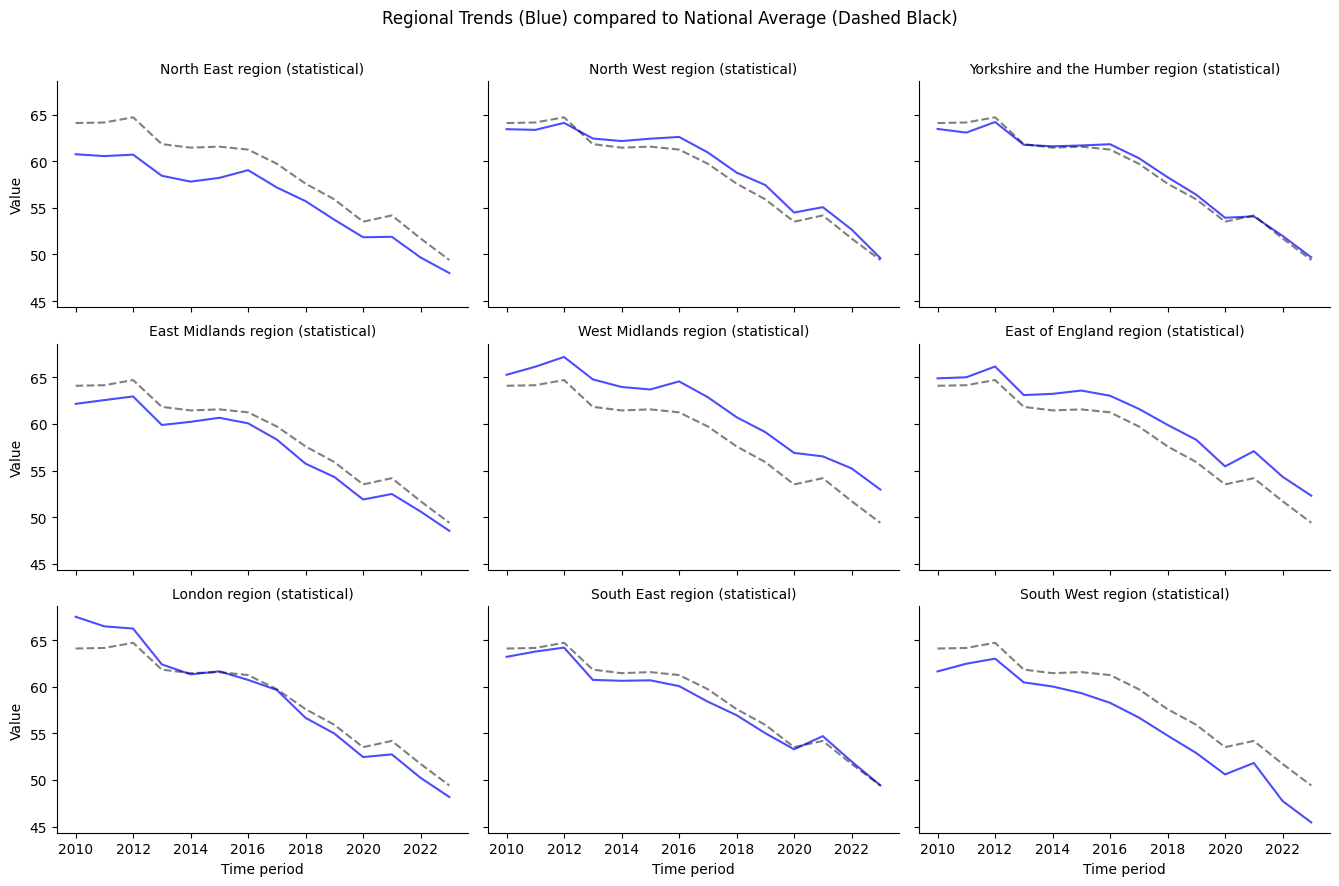

In [ ]:
# Visualisation 4: Side-by-Side Comparison

g = sns.FacetGrid(df_Regions, col="Area Name", col_wrap=3, height=3, aspect=1.5)
g.map(sns.lineplot, "Time period", "Value", color="blue", alpha=0.7)

# Overlay England trend in each
for ax in g.axes.flatten():
    sns.lineplot(data=df_england_sum, x='Time period', y='Value', color='black', ax=ax, linestyle='--', alpha=0.5)
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Regional Trends (Blue) compared to National Average (Dashed Black)')
plt.savefig('/content/drive/MyDrive/Data Viz/Processed Data/viz4_facets.png')

/tmp/ipython-input-3569794347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dist_2023, x='Value', y='Parent Name', palette='Set3')


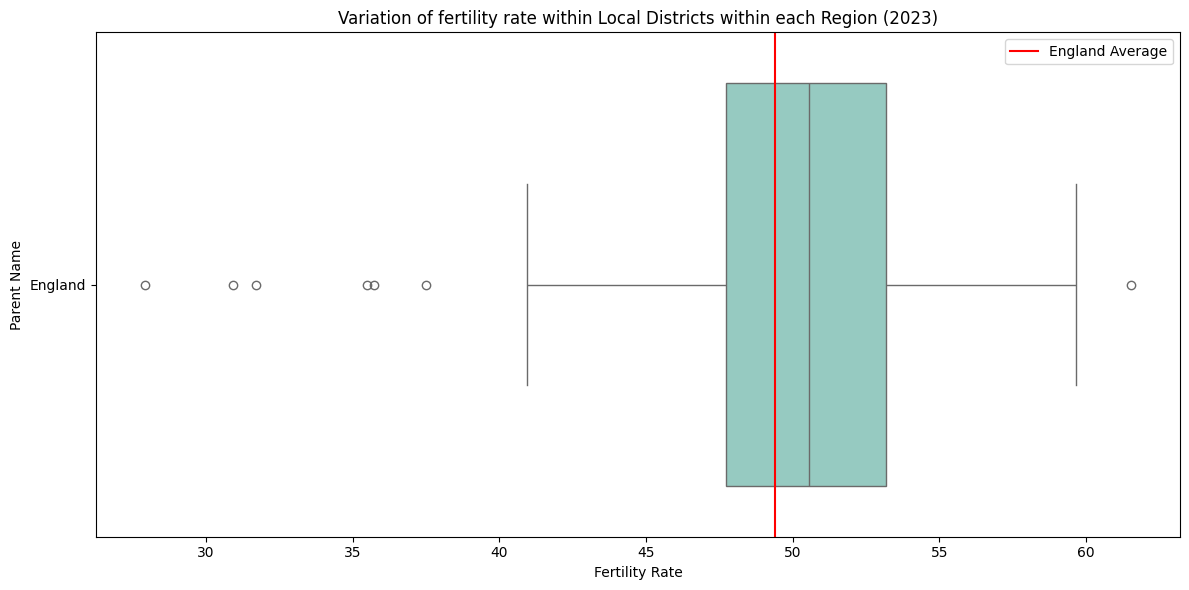

In [ ]:
#Visualisation 5: Boxplot

plt.figure(figsize=(12, 6))

# Focus on the most recent year 2023
df_dist_2023 = df_districts[df_districts['Time period'] == 2023]
sns.boxplot(data=df_dist_2023, x='Value', y='Parent Name', palette='Set3')
plt.axvline(df_england_sum[df_england_sum['Time period'] == 2023]['Value'].values[0], color='red', label='England Average')
plt.title('Variation of fertility rate within Local Districts within each Region (2023)')
plt.xlabel('Fertility Rate')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data Viz/Processed Data/viz5_facets.png')

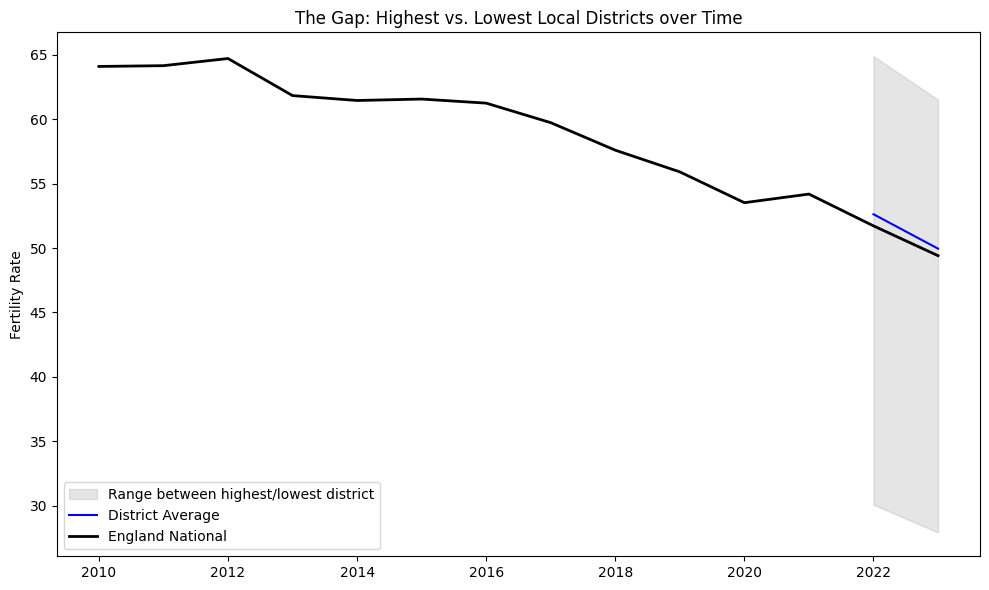

In [ ]:
#Visualisation 6

spread = df_districts.groupby('Time period')['Value'].agg(['min', 'max', 'mean']).reset_index()
plt.figure(figsize=(10, 6))
plt.fill_between(spread['Time period'], spread['min'], spread['max'], color='gray', alpha=0.2, label='Range between highest/lowest district')
plt.plot(spread['Time period'], spread['mean'], color='blue', label='District Average')
plt.plot(df_england_sum['Time period'], df_england_sum['Value'], color='black', linewidth=2, label='England National')
plt.title('The Gap: Highest vs. Lowest Local Districts over Time')
plt.ylabel('Fertility Rate')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data Viz/Processed Data/viz6_spread_gap.png')

In [ ]:
# Final check of numbers for insights to include in the report

print("England’s national fertility rate for 2010 and 2023")
print("England 2010:", df_england_sum[df_england_sum['Time period'] == 2010]['Value'].values)
print("England 2023:", df_england_sum[df_england_sum['Time period'] == 2023]['Value'].values)

print()

print("England’s maximum and minimum district fertility rate for 2023")
print("Max District 2023:", df_dist_2023['Value'].max())
print("Min District 2023:", df_dist_2023['Value'].min())

England’s national fertility rate for 2010 and 2023
England 2010: [64.09782852]
England 2023: [49.40598]

England’s maximum and minimum district fertility rate for 2023
Max District 2023: 61.52156
Min District 2023: 27.91705
